# Cell overlaps (k) on the ovrlpy grid

k = number of cell footprints (all z planes flattened) covering an ovrlpy pixel. Per sample x method:

| column | meaning |
|---|---|
| `k2_area`, `k3_area` | share of segmented pixels with k >= 2, k >= 3 |
| `k2_signal` | share of segmented signal with k >= 2 |
| `vsi_k1`, `vsi_k2` | median VSI where k == 1 vs k >= 2 |
| `patch_px` | median size of connected k >= 2 patches (slivers ~ few px, stacked cells ~ cell area) |
| `top_only`, `bottom_only` | share of cells entirely above / below the z midpoint |
| `zsplit_signal` | share of segmented signal covered by a top-only **and** a bottom-only cell |
| `lowvsi_cov` | share of low-VSI signal inside any cell |
| `lowvsi_recall` | share of low-VSI signal covered by such a top/bottom pair |

z columns are NaN for flattened boundaries (e.g. Proseg_3D in `results/`). `z_matched` checks that the
z table joins to the footprints. The z midpoint is global per method, not ovrlpy's local `z_center`.

In [1]:
SAMPLES = None                         # None = every sample with an ovrlpy output
ONLY_3D = True                         # False = every method in results/ (slow)
CONTROLS = ["Cellpose_1_DAPI_PolyT"]   # 2D controls, k >= 2 should be ~0
LOW_VSI, MIN_SIGNAL = 0.7, 3           # ovrlpy detect_doublets defaults
OFFSET = 13                            # grid offset as in metrics/ovrl.py

import pathlib, warnings, yaml
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from rasterio.features import rasterize
from rasterio.enums import MergeAlg
from scipy.ndimage import label
from spatialdata import SpatialData, read_zarr, transform
from cellseg_benchmark import BASE_PATH, _constants
from cellseg_benchmark.sdata_utils import get_2D_boundaries

warnings.filterwarnings("ignore")
BASE = pathlib.Path(BASE_PATH)
NPZ = "vertical_doublets_ovrlpy_output.npz"
META = yaml.safe_load(open(BASE / "misc" / "sample_metadata.yaml"))
if SAMPLES is None:
    SAMPLES = sorted(s for s in META if (BASE / "samples" / s / NPZ).exists())


def methods_for(sample):
    res = BASE / "samples" / sample / "results"
    have = sorted(p.name for p in res.iterdir() if (p / "sdata.zarr").exists()) if res.is_dir() else []
    if not ONLY_3D:
        return have
    return [m for m in have if m in CONTROLS or m.startswith(tuple(_constants.methods_3D))]


print(len(SAMPLES), "samples")

/home/ubuntu/miniforge3/envs/seg_postprocessing/lib/python3.12/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(


48 samples


In [2]:
DISSOLVED = ("vpt_3D", "Watershed_Merlin", "SIS")   # get_2D_boundaries dissolves these by cell_id
ZCOLS = ("ZIndex", "z_plane", "layer", "ZLevel", "z")


def load_cells(sample, method, tf):
    """One footprint per cell in ovrlpy pixels, and per-cell z range (None if flattened)."""
    raw = read_zarr(BASE / "samples" / sample / "results" / method / "sdata.zarr", selection=("shapes", "tables"))
    key = raw[next(iter(raw.tables))].uns["spatialdata_attrs"]["region"]
    sd = SpatialData()
    get_2D_boundaries(method, raw, sd, tf, key)
    foot = transform(sd[f"boundaries_{method}"], to_coordinate_system="micron")
    foot.index = foot.index.astype(str)
    if foot.index.has_duplicates:
        foot = foot.dissolve(level=0)
    foot = foot.geometry.translate(tf[0, 2] / tf[0, 0] - OFFSET, tf[1, 2] / tf[1, 1] - OFFSET)

    gdf = raw[key]
    zc = next((c for c in ZCOLS if c in gdf.columns), None)
    if zc is None:
        return foot, None
    ids = gdf["cell_id"] if method.startswith(DISSOLVED) else gdf.index
    z = pd.to_numeric(gdf[zc], errors="coerce").groupby(ids.astype(str).values).agg(["min", "max"])
    return foot, z


def count_map(geoms, shape):
    geoms = [(g, 1) for g in geoms if g is not None and not g.is_empty]
    if not geoms:
        return np.zeros(shape, np.int16)
    return rasterize(geoms, out_shape=shape, merge_alg=MergeAlg.add, dtype=np.int16)


def overlap_stats(foot, z, VSI, SIG):
    k = count_map(foot.values, VSI.shape)
    seg, multi = k >= 1, k >= 2
    valid = SIG >= MIN_SIGNAL
    low = valid & (VSI < LOW_VSI)
    out = {
        "n_cells": len(foot),
        "k2_area": multi[seg].mean(),
        "k3_area": (k >= 3)[seg].mean(),
        "k2_signal": SIG[multi].sum() / SIG[seg].sum(),
        "vsi_k1": np.median(VSI[seg & ~multi & valid]),
        "vsi_k2": np.median(VSI[multi & valid]) if (multi & valid).any() else np.nan,
        "patch_px": np.median(np.bincount(label(multi)[0].ravel())[1:]) if multi.any() else np.nan,
        "lowvsi_cov": SIG[seg & low].sum() / SIG[low].sum(),
    }
    if z is None:
        return out

    z = z.reindex(foot.index).dropna()
    mid = (z["min"].min() + z["max"].max()) / 2
    top, bot = z.index[z["min"] > mid], z.index[z["max"] < mid]
    zs = (count_map(foot.loc[top].values, VSI.shape) >= 1) & (count_map(foot.loc[bot].values, VSI.shape) >= 1)
    out.update(
        z_matched=len(z) / len(foot),
        top_only=len(top) / len(z),
        bottom_only=len(bot) / len(z),
        zsplit_signal=SIG[zs].sum() / SIG[seg].sum(),
        lowvsi_recall=SIG[zs & low].sum() / SIG[low].sum(),
    )
    return out

In [3]:
RES = globals().get("RES", {})   # rerunning this cell resumes

for s in SAMPLES:
    todo = [m for m in methods_for(s) if (s, m) not in RES]
    if not todo:
        continue
    npz = np.load(BASE / "samples" / s / NPZ)
    VSI, SIG = npz["integrity"].astype(np.float32), npz["signal"].astype(np.float32)
    tf = pd.read_csv(pathlib.Path(META[s]["path"], "images/micron_to_mosaic_pixel_transform.csv"),
                     sep=" ", header=None).values
    for m in todo:
        try:
            RES[(s, m)] = overlap_stats(*load_cells(s, m, tf), VSI, SIG)
            print(f"{s:16s} {m:40s} k>=2 signal {RES[(s, m)]['k2_signal']:.4f}")
        except Exception as e:
            print(f"{s:16s} {m:40s} ! {type(e).__name__}: {e}")

ABCAtlas_s1_r0   Baysor_3D_denovo                         k>=2 signal 0.2027
ABCAtlas_s1_r0   Cellpose_1_DAPI_PolyT                    k>=2 signal 0.0014
ABCAtlas_s1_r0   Proseg_3D_Cellpose_1_DAPI_PolyT          k>=2 signal 0.0041
ABCAtlas_s1_r0   Proseg_3D_Cellpose_1_DAPI_Transcripts    k>=2 signal 0.0043
ABCAtlas_s1_r0   Proseg_3D_Cellpose_1_nuclei_model        k>=2 signal 0.0039
ABCAtlas_s1_r0   Proseg_3D_Cellpose_2_DAPI_PolyT          k>=2 signal 0.0037
ABCAtlas_s1_r0   Proseg_3D_Cellpose_2_DAPI_Transcripts    k>=2 signal 0.0039
ABCAtlas_s1_r0   Proseg_3D_vpt3D_DAPI_PolyT               k>=2 signal 0.0053
ABCAtlas_s1_r0   Proseg_3D_vpt3D_DAPI_PolyT_nuclei        k>=2 signal 0.0053
ABCAtlas_s1_r0   Proseg_3D_vpt3D_DAPI_nuclei              k>=2 signal 0.0051
ABCAtlas_s1_r0   SIS_DAPI_total_mrna                      k>=2 signal 0.0136
ABCAtlas_s1_r0   vpt_3D_DAPI_PolyT                        k>=2 signal 0.0148
ABCAtlas_s1_r0   vpt_3D_DAPI_PolyT_nuclei                 k>=2 signal 0.0098


KeyboardInterrupt



In [4]:
df = pd.DataFrame.from_dict(RES, orient="index").rename_axis(["sample", "method"]).reset_index()
STATS = [c for c in df.columns if c not in ("sample", "method", "n_cells")]
per_method = df.groupby("method").agg(n_samples=("sample", "size"), n_cells=("n_cells", "median"),
                                      **{c: (c, "median") for c in STATS})
per_method.sort_values("k2_signal", ascending=False).round(4)

,n_samples,n_cells,k2_area,k3_area,k2_signal,vsi_k1,vsi_k2,patch_px,lowvsi_cov,z_matched,top_only,bottom_only,zsplit_signal,lowvsi_recall
method,,,,,,,,,,,,,,
Baysor_3D_denovo,20,480215.0,0.1754,0.0099,0.2051,0.9223,0.9017,2.0,0.9644,1.0,0.0957,0.1245,0.0013,0.0029
Watershed_Merlin,8,72378.0,0.0346,0.0013,0.0314,0.8532,0.8449,2.0,0.7688,1.0,0.0279,0.0329,0.0006,0.0000
vpt_3D_DAPI_PolyT,20,135025.5,0.0144,0.0002,0.0146,0.9207,0.9157,3.0,0.3745,1.0,0.0707,0.4132,0.0011,0.0006
vpt_3D_DAPI_PolyT_nuclei,19,131907.0,0.0098,0.0001,0.0100,0.9176,0.9158,1.0,0.5220,1.0,0.0229,0.3708,0.0001,0.0000
Proseg_3D_vpt3D_DAPI_PolyT,20,45353.5,0.0033,0.0000,0.0043,0.9207,0.9167,1.0,0.7186,NaN,NaN,NaN,NaN,NaN
Proseg_3D_Cellpose_1_DAPI_Transcripts,20,115521.0,0.0042,0.0000,0.0039,0.9191,0.9136,1.0,0.9940,NaN,NaN,NaN,NaN,NaN
SIS_DAPI_total_mrna,20,85323.5,0.0028,0.0000,0.0036,0.9216,0.9204,1.0,0.7102,1.0,0.0136,0.0152,0.0000,0.0000
Proseg_3D_Cellpose_2_DAPI_Transcripts,19,107529.0,0.0037,0.0000,0.0033,0.9202,0.9131,1.0,0.9912,NaN,NaN,NaN,NaN,NaN
vpt_3D_DAPI_nuclei,19,76782.0,0.0026,0.0000,0.0032,0.9165,0.9088,1.0,0.4703,1.0,0.0404,0.0233,0.0000,0.0000


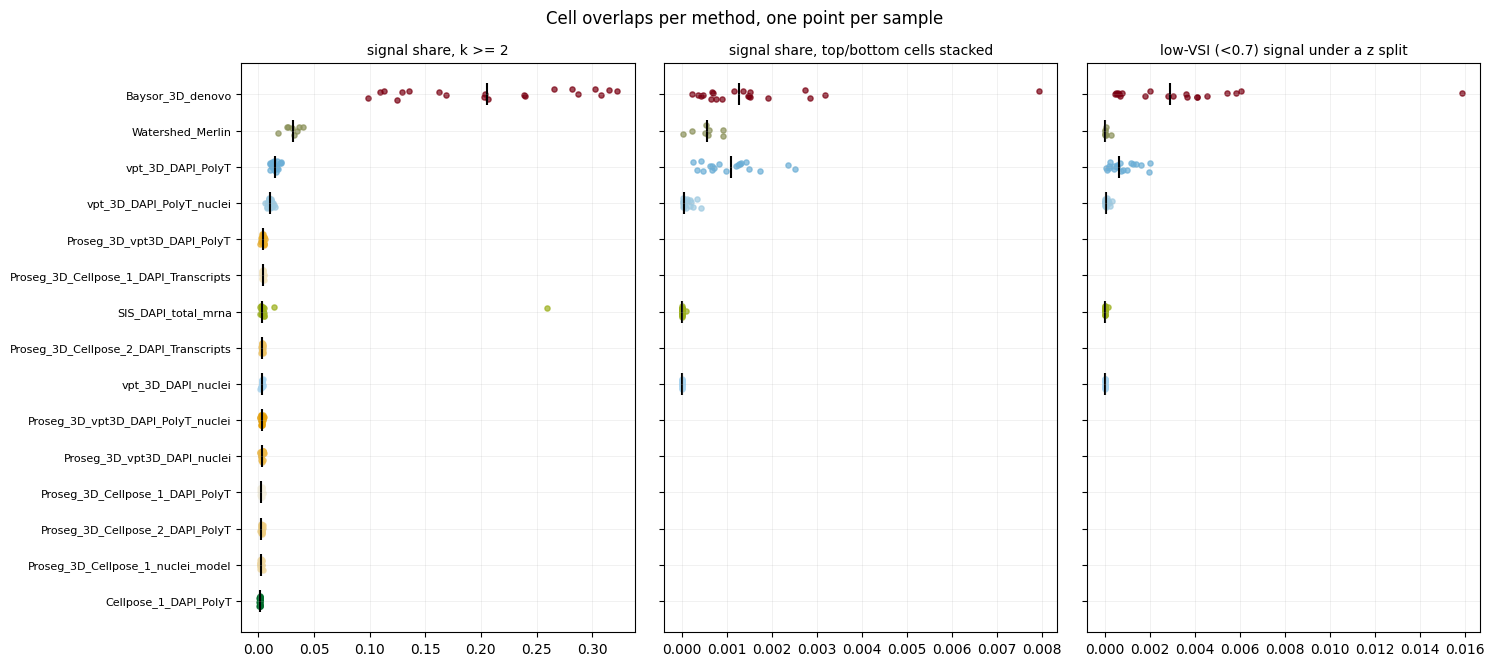

In [5]:
PANELS = {
    "k2_signal": "signal share, k >= 2",
    "zsplit_signal": "signal share, top/bottom cells stacked",
    "lowvsi_recall": f"low-VSI (<{LOW_VSI}) signal under a z split",
}
order = per_method.sort_values("k2_signal").index
clr = lambda m: _constants.method_colors.get(m, "0.4")
rng = np.random.default_rng(0)

fig, axs = plt.subplots(1, len(PANELS), figsize=(15, 0.35 * len(order) + 1.5), sharey=True)
for ax, (c, title) in zip(axs, PANELS.items()):
    for i, m in enumerate(order):
        v = df.loc[df.method == m, c].dropna()
        if v.empty:
            continue
        ax.scatter(v, i + rng.uniform(-0.15, 0.15, len(v)), s=14, alpha=0.7, color=clr(m))
        ax.scatter(v.median(), i, marker="|", s=250, color="k")
    ax.set_title(title, fontsize=10)
    ax.grid(alpha=0.25, lw=0.5)
axs[0].set_yticks(range(len(order)), order, fontsize=8)
fig.suptitle("Cell overlaps per method, one point per sample", fontsize=12)
fig.tight_layout()

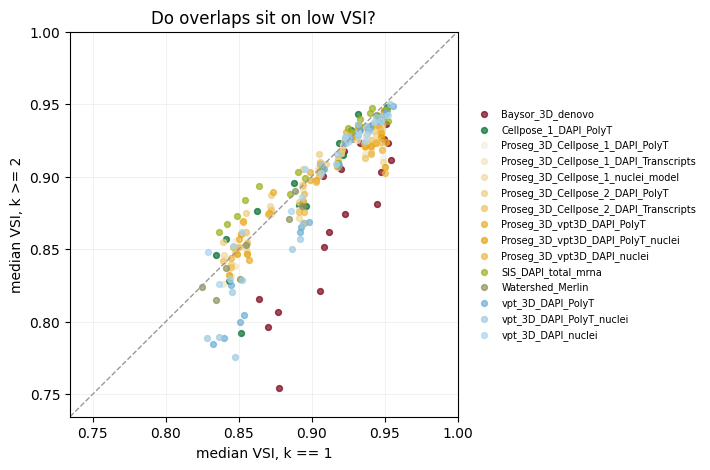

In [6]:
fig, ax = plt.subplots(figsize=(5, 5))
for m, d in df.groupby("method"):
    ax.scatter(d.vsi_k1, d.vsi_k2, s=18, alpha=0.7, color=clr(m), label=m)
lim = [df[["vsi_k1", "vsi_k2"]].min().min() - 0.02, 1]
ax.plot(lim, lim, color="0.6", ls="--", lw=1)
ax.set(xlim=lim, ylim=lim, xlabel="median VSI, k == 1", ylabel="median VSI, k >= 2",
       title="Do overlaps sit on low VSI?")
ax.grid(alpha=0.25, lw=0.5)
ax.legend(frameon=False, fontsize=7, loc="center left", bbox_to_anchor=(1.02, 0.5))

## Reading it

- `k2_signal` ~0 everywhere: overlaps are negligible, no 3D correction to VSI needed.
- `k2_signal` > 0 but `zsplit_signal` ~0: overlaps are lateral, not stacked cells.
- small `patch_px`: overlaps are boundary slivers, not cells.
- `vsi_k2` below diagonal: overlaps do sit where ovrlpy sees vertical mixing.
- `lowvsi_recall` is the one number that says whether a 3D method resolves the doublets ovrlpy finds.
- 2D controls should sit at ~0 on every panel. `z_matched` < 1 means cell ids did not join, check before reading z columns.